In [1]:
import chephy_model as cpm
import pandas as pd
import gnn_utils
import torch

/home/dsi/chenbis/anaconda3/envs/chephy2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using cache found in /home/dsi/chenbis/.cache/torch/hub/facebookresearch_esm_main


In [2]:
data_path = "../data_600_ab.csv"
df = pd.read_csv(data_path)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [3]:
import pandas as pd
import numpy as np

def make_patient_dicts_from_wide_csv(
    csv_path: str,
    patient_id_col: str = None,     # if None, use first column
    healthy_suffix: str = "_H",
    sick_suffix: str = "_OC",
    zero_tol: float = 0.0,          # use e.g. 1e-12 if you have tiny numerical noise
):
    df = pd.read_csv(csv_path)

    # pick patient id column
    if patient_id_col is None:
        patient_id_col = df.columns[0]

    # CDR3 columns are everything except patient id col
    cdr3_cols = [c for c in df.columns if c != patient_id_col]

    patient_repertoires = {}
    patient_labels = {}

    for _, row in df.iterrows():
        pid = str(row[patient_id_col])

        # ----- label -----
        if pid.endswith(healthy_suffix):
            patient_labels[pid] = 0
        elif pid.endswith(sick_suffix):
            patient_labels[pid] = 1
        else:
            raise ValueError(f"Patient id {pid} doesn't end with {healthy_suffix} or {sick_suffix}")

        # ----- repertoire -----
        vals = row[cdr3_cols].to_numpy(dtype=np.float32)
        nz_mask = vals > zero_tol

        # list of (cdr3, amount) for this patient
        seqs = np.array(cdr3_cols, dtype=object)[nz_mask]
        weights = vals[nz_mask]

        patient_repertoires[pid] = list(zip(seqs.tolist(), weights.tolist()))

    return patient_repertoires, patient_labels


In [4]:
def truncate_sequences(sequences, right=4, left=4):
    """
    Truncate sequences
    """
    
    def truncate_sequence(seq):
        if pd.isna(seq) or not isinstance(seq, str):
            return None  # Handle NaN or non-string entries gracefully
        mid = (len(seq) + 1) // 2
        return seq[max(0, mid - right):min(len(seq), mid + left)]
    
    truncated_sequences = [truncate_sequence(seq) for seq in sequences]
    
    return truncated_sequences

In [5]:
patient_repertoires, patient_labels = make_patient_dicts_from_wide_csv(
    data_path,
    patient_id_col="Unnamed: 0",  # or leave None to use the first column automatically
    zero_tol=0.0
)

from sklearn.model_selection import train_test_split

all_patients = sorted(patient_repertoires.keys())
y = np.array([patient_labels[p] for p in all_patients], dtype=int)

train_pids, test_pids = train_test_split(
    all_patients,
    test_size=0.25,
    random_state=42,
    stratify=y
)

train_reps = {p: patient_repertoires[p] for p in train_pids}
train_labels = {p: patient_labels[p] for p in train_pids}

test_reps = {p: patient_repertoires[p] for p in test_pids}
test_labels = {p: patient_labels[p] for p in test_pids}

train_cdr3_set = set()
for p in train_pids:
    for cdr3, amt in train_reps[p]:
        train_cdr3_set.add(cdr3)

train_sequences_list = sorted(train_cdr3_set)


In [6]:
sequences = list(df.columns[1:])
truncated_sequences = truncate_sequences(sequences, right=4, left=4)
sequences_set = set(truncated_sequences)

In [7]:
# Build a mapping from truncated CDR3 sequences to their original sequences
trunc_to_full = {}
for full_seq, trunc_seq in zip(sequences, truncated_sequences):
    if trunc_seq is None:
        continue
    trunc_to_full.setdefault(trunc_seq, []).append(full_seq)

# Optional: view as a DataFrame for readability
mapping_df = (
    pd.Series(trunc_to_full, name="original_sequences")
      .explode()
      .reset_index()
      .rename(columns={"index": "truncated_sequence"})
)

In [8]:
chephy_matrix, sequences_list = cpm.find_che_phy_dist(sequences_set)

In [9]:
import numpy as np
from scipy.spatial.distance import squareform

# Expand chephy_matrix (condensed) from truncated sequences to original sequences using trunc_to_full
# Uses: chephy_matrix (condensed), sequences_list (truncated order), trunc_to_full (dict), pd, squareform

# Convert to square matrix of truncated sequences
D_trunc = squareform(chephy_matrix)

# Build expansion lists per truncated sequence (fallback to the truncated seq itself if missing)
expansions = [trunc_to_full.get(s, []) for s in sequences_list]
for i, lst in enumerate(expansions):
    if not lst:
        expansions[i] = [sequences_list[i]]  # fallback

# Flat list of original sequences in expanded order
full_sequences_list = [seq for lst in expansions for seq in lst]

# Prepare expanded square matrix
sizes = [len(lst) for lst in expansions]
M = sum(sizes)
dt = getattr(chephy_matrix, "dtype", np.float32)
D_full = np.empty((M, M), dtype=dt)

# Fill blocks: distance between any originals mapped from i and j equals D_trunc[i, j]
row_start = 0
for i, ni in enumerate(sizes):
    col_start = 0
    for j, nj in enumerate(sizes):
        val = D_trunc[i, j] if i != j else dt.type(0.0)  # zero within same truncated group
        D_full[row_start:row_start + ni, col_start:col_start + nj] = val
        col_start += nj
    row_start += ni

# Outputs:
chephy_matrix_full_square = D_full
chephy_matrix_full = squareform(D_full)  # condensed form
chephy_df_full = pd.DataFrame(D_full, index=full_sequences_list, columns=full_sequences_list)

In [10]:
# Build mapping from full sequence -> index in chephy_matrix_full_square
full_idx = {s: i for i, s in enumerate(full_sequences_list)}

# Keep only train CDR3s that exist in the full matrix
train_sequences_list = [s for s in train_sequences_list if s in full_idx]

idx = np.array([full_idx[s] for s in train_sequences_list], dtype=int)
chephy_train_square = chephy_matrix_full_square[np.ix_(idx, idx)]


In [11]:
distance_threshold=0
use_mst=True
enrich=False

In [12]:
# Create scaled repertoires
# def scale_repertoire(reps_dict, scale_factor=10000):
#     """Scale all frequency values in repertoires by a constant factor."""
#     scaled = {}
#     for patient_id, repertoire in reps_dict.items():
#         scaled[patient_id] = [(seq, count * scale_factor) for seq, count in repertoire]
#     return scaled

# train_reps = scale_repertoire(train_reps, scale_factor=10000)
# test_reps = scale_repertoire(test_reps, scale_factor=10000)

In [13]:
train_data = gnn_utils.build_global_hetero_graph(
    chephy_matrix=chephy_train_square,
    sequences_list=train_sequences_list,
    patient_repertoires=train_reps,
    patient_labels=train_labels,
    distance_threshold=distance_threshold,
    use_mst=use_mst,
    enrich=enrich,          # keep your current setting
    use_edge_weights=True,
)


In [14]:
test_data = gnn_utils.build_global_hetero_graph(
    chephy_matrix=chephy_train_square,
    sequences_list=train_sequences_list,
    patient_repertoires=test_reps,
    patient_labels=test_labels,
    distance_threshold=distance_threshold,
    use_mst=use_mst,
    enrich=enrich,  
    use_edge_weights=True,
)


In [15]:
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv, Linear, MessagePassing
from torch_geometric.utils import scatter

class WeightedMeanAgg(MessagePassing):
    def __init__(self, in_channels, out_channels, eps=1e-12):
        super().__init__()
        self.lin = Linear(in_channels, out_channels)
        self.eps = eps

    def forward(self, x, edge_index, edge_attr):
        # x is (x_src, x_dst) in hetero bipartite mode
        x_src, x_dst = x

        if edge_attr is None:
            raise ValueError("edge_attr is required for TrueWeightedMeanAgg")

        # Ensure edge_attr is [E] float
        if edge_attr.dim() == 2 and edge_attr.size(-1) == 1:
            edge_attr = edge_attr.view(-1)
        elif edge_attr.dim() != 1:
            raise ValueError(f"edge_attr must be shape [E] or [E,1], got {tuple(edge_attr.shape)}")

        edge_attr = edge_attr.to(dtype=x_src.dtype)

        src, dst = edge_index  # each is [E]

        # Project src features, then gather messages for each edge
        x_src_proj = self.lin(x_src)           # [N_src, out]
        msg = x_src_proj[src] * edge_attr.unsqueeze(-1)  # [E, out]

        # Sum weighted messages into destination nodes
        num_dst = x_dst.size(0)

        out = scatter(msg, dst, dim=0, dim_size=num_dst, reduce='sum')
        wsum = scatter(edge_attr, dst, dim=0, dim_size=num_dst, reduce='sum')


        # Normalize: divide by sum of weights per destination
        out = out / (wsum.clamp_min(self.eps).unsqueeze(-1))
        return out

class HeteroRepertoireGNN(nn.Module):
    def __init__(self, cdr3_in, patient_in, hidden=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.num_layers = num_layers

        self.cdr3_proj = Linear(cdr3_in, hidden)
        self.patient_proj = Linear(patient_in, hidden)

        self.sim_convs = nn.ModuleList([GCNConv(hidden, hidden) for _ in range(num_layers)])
        self.p2s_convs = nn.ModuleList([WeightedMeanAgg(hidden, hidden) for _ in range(num_layers)])
        self.s2p_convs = nn.ModuleList([WeightedMeanAgg(hidden, hidden) for _ in range(num_layers)])

        self.classifier = nn.Sequential(
            Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            Linear(hidden, 1)
        )

    def forward(self, data):
        # initial projections
        x_cdr3 = self.cdr3_proj(data['cdr3'].x)
        x_patient = self.patient_proj(data['patient'].x)

        # edges + weights
        e_ss = data[('cdr3', 'sim', 'cdr3')].edge_index
        w_ss = data[('cdr3', 'sim', 'cdr3')].edge_weight

        e_ps = data[('patient', 'has', 'cdr3')].edge_index
        w_ps = data[('patient', 'has', 'cdr3')].edge_attr

        e_sp = data[('cdr3', 'rev_has', 'patient')].edge_index
        w_sp = data[('cdr3', 'rev_has', 'patient')].edge_attr

        # ensure w_ss is [E] float
        if w_ss.dim() == 2 and w_ss.size(-1) == 1:
            w_ss = w_ss.view(-1)
        elif w_ss.dim() != 1:
            raise ValueError(f"w_ss must be shape [E] or [E,1], got {tuple(w_ss.shape)}")
        w_ss = w_ss.to(dtype=x_cdr3.dtype)

        for k in range(self.num_layers):
            # 1) cdr3 <-> cdr3 (GCN with similarity weights)
            x_cdr3 = self.sim_convs[k](x_cdr3, e_ss, edge_weight=w_ss)
            x_cdr3 = F.relu(x_cdr3)
            x_cdr3 = F.dropout(x_cdr3, p=self.dropout, training=self.training)

            # 2) patient -> cdr3 (your weighted mean agg)
            x_cdr3 = x_cdr3 + self.p2s_convs[k]((x_patient, x_cdr3), e_ps, w_ps)
            x_cdr3 = F.relu(x_cdr3)

            # 3) cdr3 -> patient (your weighted mean agg)
            x_patient = x_patient + self.s2p_convs[k]((x_cdr3, x_patient), e_sp, w_sp)
            x_patient = F.relu(x_patient)
            x_patient = F.dropout(x_patient, p=self.dropout, training=self.training)

        logits = self.classifier(x_patient).view(-1)
        return logits

In [16]:
def train_epoch(model, data, optimizer, train_mask):
    model.train()
    optimizer.zero_grad()
    logits = model(data)
    y = data['patient'].y.float()
    loss = F.binary_cross_entropy_with_logits(logits[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()
    return float(loss)

@torch.no_grad()
def eval_auc_acc(model, data, mask):
    model.eval()
    logits = model(data)
    probs = torch.sigmoid(logits[mask])
    y = data['patient'].y[mask].float()
    pred = (probs >= 0.5).float()
    acc = (pred == y).float().mean().item()
    # AUC if you want: use sklearn.metrics.roc_auc_score on CPU arrays.
    return acc


In [17]:
model = HeteroRepertoireGNN(
    cdr3_in=train_data['cdr3'].x.size(-1),
    patient_in=train_data['patient'].x.size(-1),
    hidden=128,
    num_layers=2,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, 201):
    loss = train_epoch(model, train_data, optimizer,
                       train_mask=torch.ones(train_data['patient'].x.size(0), dtype=torch.bool, device=device))
    if epoch % 10 == 0:
        # you can make a val split from train_pids if you want
        print(epoch, loss)


10 0.6676369309425354
20 0.6879766583442688
30 0.6688539385795593
40 0.6824637055397034
50 0.6770099997520447
60 0.6767151951789856
70 0.6698532104492188
80 0.6411216259002686
90 0.6382735371589661
100 0.5518603324890137
110 0.4720059633255005
120 0.4660613536834717
130 0.45342499017715454
140 0.4479057192802429
150 0.4057430028915405
160 0.4382728338241577
170 0.39763665199279785
180 0.38536807894706726
190 0.3779081404209137
200 0.40897849202156067


In [18]:
test_mask = torch.ones(test_data['patient'].x.size(0), dtype=torch.bool, device=device)
test_acc = eval_auc_acc(model, test_data, test_mask)
print("TEST ACC:", test_acc)


TEST ACC: 0.761904776096344


In [19]:
import numpy as np
import pandas as pd
import torch

def _prepare_edge_weights_for_grad(data):
    """Return (data_tmp, edge_index, w) where w requires grad and is used on both directions."""
    edge_store = data[('patient', 'has', 'cdr3')]
    edge_index = edge_store.edge_index  # [2, E]
    w = edge_store.edge_attr
    if w is None:
        raise ValueError("Missing edge_attr on ('patient','has','cdr3')")

    # shape [E]
    w = w.clone().detach().float()
    if w.dim() == 2 and w.size(-1) == 1:
        w = w.view(-1)
    if w.dim() != 1:
        raise ValueError(f"edge_attr must be [E] or [E,1], got {tuple(w.shape)}")

    w.requires_grad_(True)

    data_tmp = data.clone()
    data_tmp[('patient', 'has', 'cdr3')].edge_attr = w
    # keep reverse edge weights consistent if used
    if ('cdr3', 'rev_has', 'patient') in data_tmp.edge_types:
        data_tmp[('cdr3', 'rev_has', 'patient')].edge_attr = w

    return data_tmp, edge_index, w


@torch.no_grad()
def top_cdr3_abs_contributors_for_patient(
    model, data, patient_idx: int, sequences_list, topk: int = 20
):
    """
    NOTE: This wrapper just formats output.
    Actual gradients are computed in the function below (without no_grad).
    """
    raise RuntimeError("Call top_cdr3_abs_contributors_for_patient_with_grads instead.")


def top_cdr3_abs_contributors_for_patient_with_grads(
    model, data, patient_idx: int, sequences_list, topk: int = 20
):
    """
    Top-K CDR3s by absolute contribution for one patient:
        contrib_edge = abs(grad_w * w)
        contrib_cdr3 = sum over patient's edges into that cdr3
    """
    model.eval()

    data_tmp, edge_index, w = _prepare_edge_weights_for_grad(data)

    logits = model(data_tmp)  # [num_patients]
    target = logits[patient_idx]

    model.zero_grad(set_to_none=True)
    if w.grad is not None:
        w.grad.zero_()
    target.backward()

    # absolute edge attributions
    edge_attr_abs = (w.grad * w).abs().detach()  # [E]

    src_pat = edge_index[0]
    dst_cdr3 = edge_index[1]

    mask = (src_pat == patient_idx)
    cdr3_ids = dst_cdr3[mask]
    contribs = edge_attr_abs[mask]

    num_cdr3 = data['cdr3'].x.size(0)
    cdr3_score = torch.zeros(num_cdr3, device=contribs.device)
    cdr3_score.index_add_(0, cdr3_ids, contribs)

    k = min(topk, num_cdr3)
    top_vals, top_idx = torch.topk(cdr3_score, k=k)

    out = pd.DataFrame({
        "cdr3_idx": top_idx.cpu().numpy(),
        "CDR3_sequence": [sequences_list[i] for i in top_idx.cpu().numpy()],
        "abs_contribution": top_vals.cpu().numpy()
    }).sort_values("abs_contribution", ascending=False).reset_index(drop=True)

    out["rank"] = np.arange(1, len(out) + 1)
    return out[["rank", "CDR3_sequence", "abs_contribution", "cdr3_idx"]]


def global_cdr3_abs_importance(
    model, data, sequences_list, patient_indices=None, topk: int = 50, reduce: str = "sum"
):
    """
    Global absolute importance across many patients.
    reduce: "sum" or "mean" over patients.
    """
    model.eval()

    n_pat = data['patient'].x.size(0)
    n_cdr3 = data['cdr3'].x.size(0)

    if patient_indices is None:
        patient_indices = list(range(n_pat))
    else:
        patient_indices = list(patient_indices)

    scores = np.zeros(n_cdr3, dtype=np.float64)

    # compute per-patient abs contributions and accumulate
    for pidx in patient_indices:
        df_p = top_cdr3_abs_contributors_for_patient_with_grads(
            model, data, patient_idx=pidx, sequences_list=sequences_list, topk=n_cdr3
        )
        # df_p currently contains all cdr3 if topk=n_cdr3; accumulate by idx
        for cid, sc in zip(df_p["cdr3_idx"].values, df_p["abs_contribution"].values):
            scores[int(cid)] += float(sc)

    if reduce == "mean":
        scores = scores / max(1, len(patient_indices))

    order = np.argsort(scores)[::-1][:min(topk, n_cdr3)]
    out = pd.DataFrame({
        "rank": np.arange(1, len(order) + 1),
        "CDR3_sequence": [sequences_list[i] for i in order],
        "abs_contribution": scores[order],
        "cdr3_idx": order
    })
    return out


In [20]:
df_top_global_mean = global_cdr3_abs_importance(
    model, train_data, sequences_list=train_sequences_list, topk=50, reduce="mean"
)
print(df_top_global_mean.head(20))


    rank     CDR3_sequence  abs_contribution  cdr3_idx
0      1      CAVMDSNYQLIW          0.544244       421
1      2      CAVRDSNYQLIW          0.249323       483
2      3      CAVLDSNYQLIW          0.187740       408
3      4   CVVSDRGSTLGRLYF          0.126138       598
4      5      CAAMDSNYQLIW          0.094241        15
5      6      CAVTDSNYQLIW          0.083702       558
6      7      CAPMDSNYQLIW          0.069095       213
7      8       CAVNNNARLMF          0.061192       433
8      9  CADHQNYGGSQGNLIF          0.060270       114
9     10      CAVKDSNYQLIW          0.052826       405
10    11       CAVYNNNDMRF          0.050176       577
11    12      CAVMDSSYKLIF          0.048116       422
12    13      CAALDSNYQLIW          0.046156        12
13    14      CAGMDSNYQLIW          0.045435       144
14    15      CAVNTGGFKTIF          0.044538       448
15    16      CAVSDSNYQLIW          0.040490       523
16    17  CALSAARSSNTGKLIF          0.034145       193
17    18  

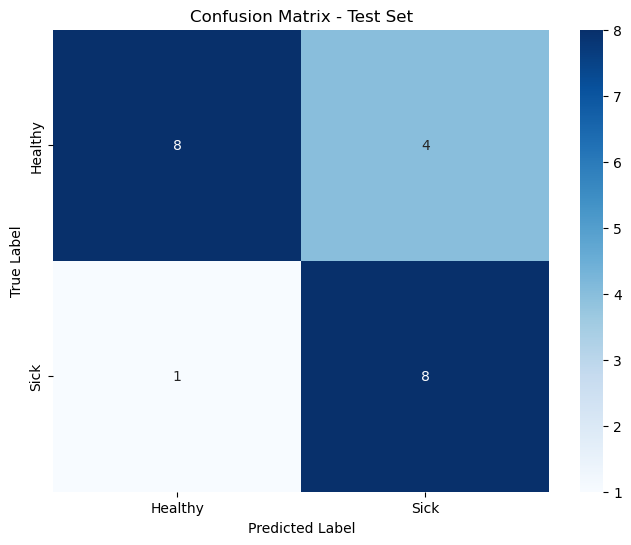

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Get predictions on test set
model.eval()
with torch.no_grad():
    logits = model(test_data)
    probs = torch.sigmoid(logits)
    predictions = (probs >= 0.5).float().cpu().numpy()

# Get true labels
true_labels = test_data['patient'].y.cpu().numpy()

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Sick'], 
            yticklabels=['Healthy', 'Sick'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Test Set')
plt.show()

In [22]:
from pathlib import Path
import json

out_dir = Path("outputs")
out_dir.mkdir(parents=True, exist_ok=True)

# Save performance metrics
metrics = {
    "test_acc": float(test_acc),
    "num_test_patients": int(len(test_pids)),
}
with (out_dir / "metrics.json").open("w") as f:
    json.dump(metrics, f, indent=2)

# Save predictions
pred_df = pd.DataFrame({
    "patient_id": test_pids,
    "true_label": true_labels.tolist(),
    "pred_label": predictions.tolist(),
    "prob": probs.detach().cpu().numpy().tolist(),
})
pred_df.to_csv(out_dir / "test_predictions.csv", index=False)

# Save CDR3 importance (global mean)
df_top_global_mean.to_csv(out_dir / "cdr3_importance_global_mean.csv", index=False)